In [1]:
import sys
sys.path.append("..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from DicomToNumpyClass import DicomToNumpy
from preprocessor.preprocessor import CTManager
from brain_extraction.brain_extractor import BrainExtractorManager

In [3]:
processor = DicomToNumpy("../Brain_Stroke_CT_Dataset")
subdataset = processor.get_subset(limit = 1000) # tomo solo las 1000 primeras imágenes
subdataset_filtered = CTManager.process_batch_clean_image(subdataset)
subdataset_filtered = BrainExtractorManager(subdataset_filtered).extract_all_brains(plot_examples=False)

Cargando subconjunto de datos (Primeras 1000 imágenes)...
  -> Cargado subconjunto Bleeding: (1000, 512, 512)
  -> Cargado subconjunto Ischemia: (1000, 512, 512)
  -> Cargado subconjunto Normal: (1000, 512, 512)
Iniciando extracción de cerebros...
  -> Procesando clase: Bleeding (1000 imágenes)
  -> Procesando clase: Ischemia (1000 imágenes)
  -> Procesando clase: Normal (1000 imágenes)
Extracción completada.


In [4]:
from RandomForest.utils import split_dataset_3way
train_data, val_data, test_data = split_dataset_3way(subdataset_filtered,  train_qty=600, val_qty=200)

--------------------------------------------------
SEPARACIÓN 3-WAY (Train: 600 | Val: 200 | Test: Resto)
--------------------------------------------------
[Normal] -> Train: 600 | Val: 200 | Test: 200
[Bleeding] -> Train: 600 | Val: 200 | Test: 200
[Ischemia] -> Train: 600 | Val: 200 | Test: 200


In [5]:
from kernel_extraction.kernel_extractor import KernelExtractorManager
from sklearn.ensemble import RandomForestClassifier

In [7]:
# Instanciamos el manager solo pasándole los datos
kernel_manager_train = KernelExtractorManager(train_data)

# Extraemos todo automáticamente (ya no hay límite por lesión, extrae todas las que encuentre)
kernels_train = kernel_manager_train.extract_all()

Iniciando extracción por componentes conectados (Lesion-Centric) con Muestreo Proporcional...
  -> Minando lesiones completas de Bleeding...
  -> Minando lesiones completas de Ischemia...

Total bruto extraído: 19557 Bleeding, 100968 Ischemia.
  -> Aplicando Undersampling: Recortando a 19557 parches por clase...
  -> Procesando Normal: Buscando exactamente 19557 parches con formas específicas...
--------------------------------------------------
RESUMEN DE KERNELS EXTRAÍDOS (BALANCE ESTRICTO 1:1:1):
[Bleeding]: 19557 parches anatómicos.
[Ischemia]: 19557 parches anatómicos.
[Normal]: 19426 parches anatómicos.
--------------------------------------------------


In [8]:
# Instanciamos el manager solo pasándole los datos
kernel_manager_val = KernelExtractorManager(val_data)

# Extraemos todo automáticamente (ya no hay límite por lesión, extrae todas las que encuentre)
kernels_val = kernel_manager_val.extract_all()

Iniciando extracción por componentes conectados (Lesion-Centric) con Muestreo Proporcional...
  -> Minando lesiones completas de Bleeding...
  -> Minando lesiones completas de Ischemia...

Total bruto extraído: 6709 Bleeding, 34062 Ischemia.
  -> Aplicando Undersampling: Recortando a 6709 parches por clase...
  -> Procesando Normal: Buscando exactamente 6709 parches con formas específicas...
--------------------------------------------------
RESUMEN DE KERNELS EXTRAÍDOS (BALANCE ESTRICTO 1:1:1):
[Bleeding]: 6709 parches anatómicos.
[Ischemia]: 6709 parches anatómicos.
[Normal]: 6676 parches anatómicos.
--------------------------------------------------


In [9]:
from feature_analysis.feature_extract import FeatureExtractManager
print("Extrayendo features de los kernels de entrenamiento...")
feature_manager = FeatureExtractManager(kernels_train)
df_train = feature_manager.extract_all_to_dataframe()

Extrayendo features de los kernels de entrenamiento...
Iniciando extracción radiómica (First-Order, GLCM, LDOP-Gradients)...
  -> Minando características para clase: Bleeding (19557 parches)
  -> Minando características para clase: Ischemia (19557 parches)
  -> Minando características para clase: Normal (19426 parches)
--------------------------------------------------
EXTRACCIÓN COMPLETADA.
Dataset estructurado final: 58540 filas (ejemplos) x 15 columnas (features + label)
--------------------------------------------------


In [10]:
best_features = ['variance', 
                 'glcm_correlation', 
                 #'energy_1st', 
                 'glcm_entropy', 
                 'skewness', 
                 'kurtosis', 
                 'mean_hu']

In [11]:
X_train = df_train[best_features]
y_train = df_train['label']

In [12]:
print("Entrenando el Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

Entrenando el Random Forest...


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
# hago una prueba con mi validación para ver qué tan bien se desempeña el modelo con los kernels extraídos
print("Evaluando en el set de validación...")
feature_manager_val = FeatureExtractManager(kernels_val)
df_val = feature_manager_val.extract_all_to_dataframe()
X_val = df_val[best_features]
y_val = df_val['label']
val_score = rf_model.score(X_val, y_val)
print(f"Accuracy en validación: {val_score:.4f}")

Evaluando en el set de validación...
Iniciando extracción radiómica (First-Order, GLCM, LDOP-Gradients)...
  -> Minando características para clase: Bleeding (6709 parches)
  -> Minando características para clase: Ischemia (6709 parches)
  -> Minando características para clase: Normal (6676 parches)
--------------------------------------------------
EXTRACCIÓN COMPLETADA.
Dataset estructurado final: 20094 filas (ejemplos) x 15 columnas (features + label)
--------------------------------------------------
Accuracy en validación: 0.6839


In [14]:
from RandomForest.random_forest import plot_rf_test_results


--- FASE 3: EVALUACIÓN VISUAL (Bleeding) ---
Evaluando escalas: [5, 10, 15, 20] (Movimiento al 50% de cada parche)
Evaluando 2 pacientes...


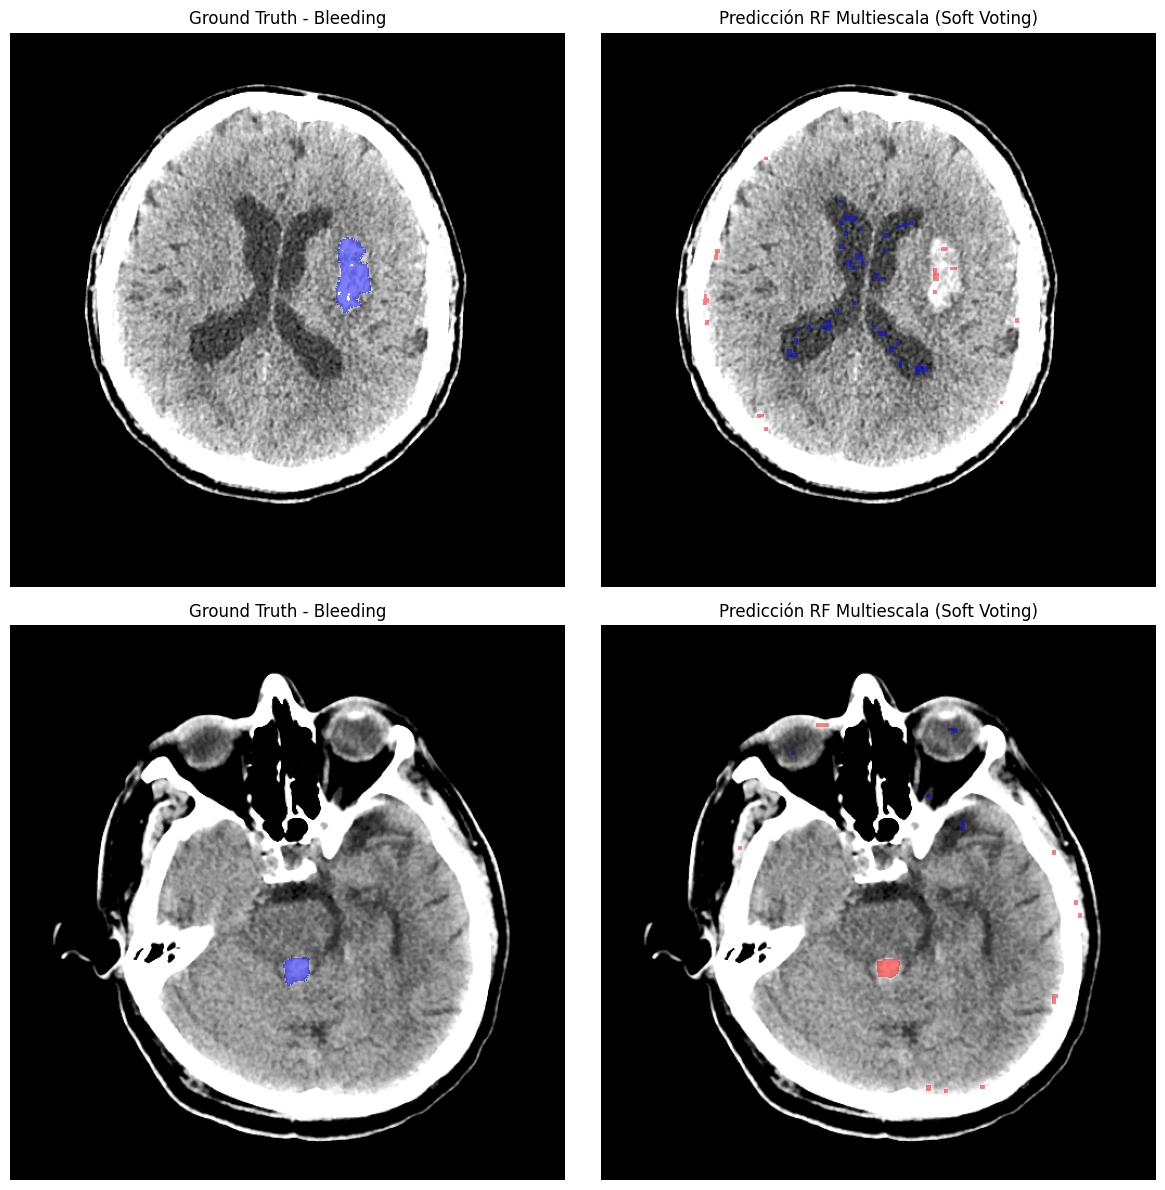

In [15]:
plot_rf_test_results(
    test_dataset=test_data, 
    cls_target='Bleeding', 
    model=rf_model, 
    best_features=best_features, 
    patch_sizes=[5, 10, 15, 20], # ¡El ensamble de escalas!
)


--- FASE 3: EVALUACIÓN VISUAL (Ischemia) ---
Evaluando escalas: [5, 10, 15, 20] (Movimiento al 50% de cada parche)
Evaluando 2 pacientes...


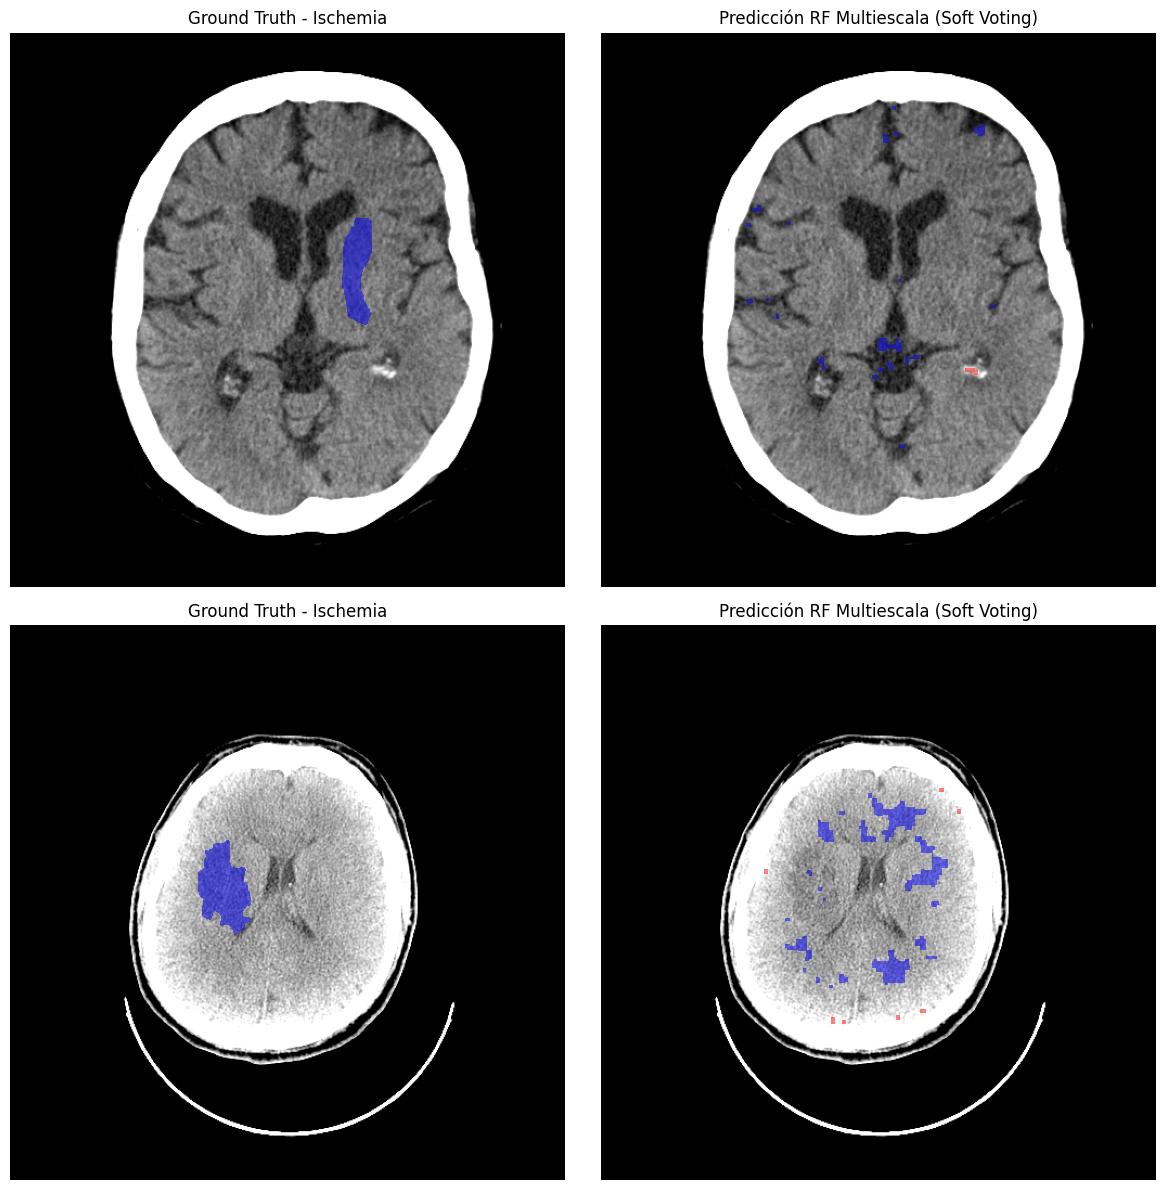

In [16]:
plot_rf_test_results(
    test_dataset=test_data, 
    cls_target='Ischemia', 
    model=rf_model, 
    best_features=best_features, 
    patch_sizes=[5, 10, 15, 20], # ¡El ensamble de escalas!
)

In [17]:
# almacenar el modelo de Random Forest entrenado para su uso posterior
import joblib
joblib.dump(rf_model, 'rf_model.pkl')

['rf_model.pkl']